# XAI Enhancement Playground

24 × 5 t-SNE grid iterated over multiple experiment folders.

**Color encoding** — hue family = class · shade = concentration (light → low, dark → high)

In [1]:
import os, sys
from pathlib import Path
try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb: os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import types as _types
import colorsys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import joblib
import tensorflow as tf
from pathlib import Path
import umap
from sklearn.metrics import silhouette_score

import config
import model_utils_gated
import model_utils_mtl
import model_utils_supcon
from model_utils_mtl    import CurriculumMTLModel
from model_utils_rcfd   import (RCFDModel, RCFDSupConMTLModel,
                                 RCFDBranch2MTLModel, RCFDBranch3MTLModel)
from model_utils_supcon import (SupConModel, SupConMTLModel,
                                 SupConBranch2STModel,  SupConBranch2MTLModel,
                                 SupConBranch3STModel,  SupConBranch3MTLModel,
                                 CurriculumSupConMTLModel,
                                 CurriculumBranch2MTLModel,
                                 CurriculumBranch3MTLModel,
                                 StagedSupConSTModel,
                                 StagedBranch2STModel,
                                 StagedBranch3STModel)
print('TF:', tf.__version__)

2026-07-16 08:28:20.732335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-16 08:28:20.752272: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-16 08:28:20.752314: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-16 08:28:20.765226: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-16 08:28:24.408491: W tensorflow/com


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

TF: 2.16.2


In [3]:
# ── Keras 3 compat: Lambda layers in old .keras files ────────────────────────
tf.keras.layers.Lambda.compute_output_shape = lambda self, input_shape=None: input_shape

_orig_lambda_call = tf.keras.layers.Lambda.call
def _lambda_call_tf_fix(self, inputs, mask=None, training=None):
    fn = self.function
    if fn is not None and callable(fn) and 'tf' not in fn.__globals__:
        self.function = _types.FunctionType(
            fn.__code__, {**fn.__globals__, 'tf': tf},
            fn.__name__, fn.__defaults__, fn.__closure__)
    return _orig_lambda_call(self, inputs, mask=mask, training=training)
tf.keras.layers.Lambda.call = _lambda_call_tf_fix
print('Lambda patches applied.')

Lambda patches applied.


In [4]:
# ── Grid constants (shared across all folders) ────────────────────────────────
_BACKBONES  = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']
_BB_LABELS  = ['CNN', 'GRU', 'Trans', 'CNN+GRU', 'CNN+Trans']
_BB_KEY_PFX = {'transformer': 'trans'}

_FAMILIES = [
    ('ST',         'ST'),
    ('MTL',        'MTL'),
    ('CL',         'CL'),
    ('CNN RCFD',   'CNN_RCFD'),
    ('GRU RCFD',   'GRU_RCFD'),
    ('Trans RCFD', 'TRANS_RCFD'),
    ('Staged',      'STAGED'),
]
_RCFD_ENC_TAG = {'CNN_RCFD': 'cnn', 'GRU_RCFD': 'gru', 'TRANS_RCFD': 'trans'}
_SC_VARIANTS  = [0, 1, 2, 3]
_N_ROWS       = len(_FAMILIES) * 4
_N_COLS       = len(_BACKBONES)


def _combo_key(family, sc, bb):
    pfx = _BB_KEY_PFX.get(bb, bb)
    if family == 'ST':
        sfx = {0: '', 1: '_supcon', 2: '_supcon2', 3: '_supcon3'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        return f'{pfx}{sfx}'
    if family == 'MTL':
        sfx = {0: '_mtl', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        return f'{pfx}{sfx}'
    if family == 'CL':
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        sfx = {0: '_cl_mtl', 1: '_cl_supcon_mtl', 2: '_cl_supcon2_mtl', 3: '_cl_supcon3_mtl'}[sc]
        return f'{pfx}{sfx}'
    if family in _RCFD_ENC_TAG:
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        enc  = _RCFD_ENC_TAG[family]
        dual = 'cgd' if bb == 'cnn_gru_dual' else 'ctd'
        sfx  = {0: '', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        return f'{enc}_rcfd_{dual}{sfx}'
    if family == 'STAGED':
        if bb != 'cnn_gru_dual':
            return None
        sfx = {1: '_supcon_staged', 2: '_supcon2_staged', 3: '_supcon3_staged'}.get(sc)
        if sfx is None:
            return None  # SC 0 not valid for staged
        return f'cnn_gru_dual{sfx}'
    return None


def _key_to_filename(key):
    """Result-storage key → .keras file stem (gru→bigru, trans*→transformer*)."""
    if key is None: return None
    if key == 'gru': return 'bigru'
    if key.startswith('trans') and 'rcfd' not in key:
        return 'transformer' + key[len('trans'):]
    return key


# Pre-built grid list — (row_idx, row_label, col_idx, col_label, combo_key, file_stem)
_GRID = [
    (fi * 4 + si, f'{fl} SC{sc}', ci, _BB_LABELS[ci],
     _combo_key(ft, sc, bb), _key_to_filename(_combo_key(ft, sc, bb)))
    for fi, (fl, ft) in enumerate(_FAMILIES)
    for si, sc    in enumerate(_SC_VARIANTS)
    for ci, bb    in enumerate(_BACKBONES)
]

# Custom objects for load_model
_CUSTOM_OBJECTS = {
    'SupConModel':               SupConModel,
    'SupConMTLModel':            SupConMTLModel,
    'SupConBranch2STModel':      SupConBranch2STModel,
    'SupConBranch2MTLModel':     SupConBranch2MTLModel,
    'SupConBranch3STModel':      SupConBranch3STModel,
    'SupConBranch3MTLModel':     SupConBranch3MTLModel,
    'CurriculumMTLModel':        CurriculumMTLModel,
    'CurriculumSupConMTLModel':  CurriculumSupConMTLModel,
    'CurriculumBranch2MTLModel': CurriculumBranch2MTLModel,
    'CurriculumBranch3MTLModel': CurriculumBranch3MTLModel,
    'RCFDModel':                 RCFDModel,
    'RCFDSupConMTLModel':        RCFDSupConMTLModel,
    'RCFDBranch2MTLModel':       RCFDBranch2MTLModel,
    'RCFDBranch3MTLModel':       RCFDBranch3MTLModel,
}

print(f'Grid: {_N_ROWS} rows x {_N_COLS} cols, '
      f'{sum(k is not None for *_,k,_ in _GRID)} valid cells')
# -- CNN+GRU Dual sub-grid: family (rows) x SC variant (cols) --------------
_GRU_GRID = [
    (fi, fl, si, f'SC{sc}',
     _combo_key(ft, sc, 'cnn_gru_dual'),
     _key_to_filename(_combo_key(ft, sc, 'cnn_gru_dual')))
    for fi, (fl, ft) in enumerate(_FAMILIES)
    for si, sc    in enumerate(_SC_VARIANTS)
]
_GRU_N_ROWS = len(_FAMILIES)    # 6
_GRU_N_COLS = len(_SC_VARIANTS) # 4
print(f'GRU grid: {_GRU_N_ROWS} rows x {_GRU_N_COLS} cols, '
      f'{sum(k is not None for *_,k,_ in _GRU_GRID)} valid cells')


Grid: 28 rows x 5 cols, 63 valid cells
GRU grid: 7 rows x 4 cols, 27 valid cells


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# Helper functions
# ════════════════════════════════════════════════════════════════════════════

def _conc_label(v):
    """Human-readable concentration: 1_000_000 -> '1M', 10_000 -> '10K', etc."""
    if np.isnan(v): return 'unknown'
    if v >= 1e6:    return f'{v/1e6:.4g}M'
    if v >= 1e3:    return f'{v/1e3:.4g}K'
    return f'{v:.4g}'


def _build_latent_model(model):
    """Latent extractor: cls_feat layer preferred, falls back to layers[-2]."""
    try:
        return tf.keras.Model(model.input, model.get_layer('cls_feat').output)
    except (ValueError, KeyError):
        return tf.keras.Model(model.input, model.layers[-2].output)


# ── Data ─────────────────────────────────────────────────────────────────────

def load_dataset(folder, curve_type=None):
    """Load curves, labels, concentration for one experiment folder."""
    ct        = curve_type or CURVE_TYPE
    data_path = Path(config.LAB_EXP_FOLDER) / folder / config.TRAINING_DATA_PATH
    if not data_path.exists():
        print(f'  [!] {folder}: data file not found')
        return None
    data = joblib.load(data_path)
    try:
        curve_idx, dataset_name = config.resolve_curve_dataset_idx(
            ct, list(data['dataset_name']))
    except ValueError as e:
        print(f'  [SKIP] {folder}: {e}')
        return None

    X_all        = np.array(data['dataset'][curve_idx], dtype=np.float32)[..., np.newaxis]
    y_labels_all = np.array(data['Y_well'])
    conc_all     = np.array(data['concentration'], dtype=float)
    has_conc     = not np.all(np.isnan(conc_all))

    return dict(
        X_all        = X_all,
        y_labels_all = y_labels_all,
        conc_all     = conc_all,
        T            = X_all.shape[1],
        unique_cls   = sorted(np.unique(y_labels_all)),
        unique_concs = (sorted(np.unique(conc_all[~np.isnan(conc_all)]))
                        if has_conc else []),
        has_conc     = has_conc,
        folder       = folder,
        dataset_name = dataset_name,
    )


# ── Models ───────────────────────────────────────────────────────────────────

def load_models(folder, expected_T, curve_type=None, filter_key=None):
    """Load all grid model files for *folder*. Returns {combo_key: model or None}."""
    ct        = curve_type or CURVE_TYPE
    fk        = filter_key if filter_key is not None else FILTER_KEY
    model_dir = Path(config.LAB_EXP_FOLDER) / folder / 'model_interpretation'
    fk_str    = str(fk)
    models    = {}

    for _, _, _, _, key, fn in _GRID:
        if key is None or key in models:
            continue
        path = model_dir / f'{fn}_{fk_str}_{ct}_model.keras'
        if not path.exists():
            models[key] = None
            continue
        try:
            m      = tf.keras.models.load_model(
                path, safe_mode=False, custom_objects=_CUSTOM_OBJECTS)
            in_shp = m.input_shape
            mT     = in_shp[0][1] if isinstance(in_shp, list) else in_shp[1]
            if mT != expected_T:
                print(f'    [SKIP] {key}: T={mT} != {expected_T}')
                models[key] = None
            else:
                models[key] = m
        except Exception as e:
            print(f'    [!] {key}: {e}')
            models[key] = None

    n_ok = sum(v is not None for v in models.values())
    print(f'  Models: {n_ok}/{len(models)} loaded')
    return models


# ── Batch ────────────────────────────────────────────────────────────────────

def prepare_batch(dataset, max_samples=None, seed=42):
    """Stratified sample covering every (class x discrete-concentration) group."""
    cap          = max_samples or MAX_SAMPLES
    rng          = np.random.default_rng(seed)
    y_all        = dataset['y_labels_all']
    c_all        = dataset['conc_all']
    unique_cls   = dataset['unique_cls']
    unique_concs = dataset['unique_concs']
    has_conc     = dataset['has_conc']

    if has_conc:
        groups = {}
        for cls in unique_cls:
            for cv in unique_concs:
                mask = (y_all == cls) & (c_all == cv)
                if mask.any(): groups[(cls, cv)] = np.where(mask)[0]
            nan_mask = (y_all == cls) & np.isnan(c_all)
            if nan_mask.any(): groups[(cls, np.nan)] = np.where(nan_mask)[0]
        n_per    = max(50, cap // max(len(groups), 1))
        selected = [idx for g in groups.values()
                    for idx in rng.choice(g, size=min(n_per, len(g)), replace=False)]
    else:
        n_per    = cap // max(len(unique_cls), 1)
        selected = [idx for cls in unique_cls
                    for idx in rng.choice(
                        np.where(y_all == cls)[0],
                        size=min(n_per, (y_all == cls).sum()), replace=False)]

    selected = np.sort(np.unique(selected))
    if len(selected) > cap:
        selected = np.sort(rng.choice(selected, size=cap, replace=False))

    return dataset['X_all'][selected], y_all[selected], c_all[selected]


# ── Colors ───────────────────────────────────────────────────────────────────
# Strategy: 10 maximally distinct hues, each a light→dark gradient for concentration.
# Hues are unevenly spaced to account for perceptual non-linearity — green/cyan region
# is compressed, red/orange/yellow gets more spread to avoid crowding.
#
#   hue=0  (0°)   red          hue=5  (180°) cyan
#   hue=1  (30°)  orange       hue=6  (210°) sky blue
#   hue=2  (65°)  yellow-green hue=7  (250°) blue
#   hue=3  (110°) green        hue=8  (290°) purple/violet
#   hue=4  (150°) teal         hue=9  (330°) pink/magenta

# _DISTINCT_HUES = [0/360, 30/360, 65/360, 110/360, 150/360,
#                   180/360, 210/360, 250/360, 290/360, 330/360]
# _CMAP_LO, _CMAP_HI = 0.08, 0.95   # wider range → more visible concentration gradient


# def _hue_cmap(hue):
#     """HSV colormap: near-white tint (low conc) → vivid saturated color (high conc)."""
#     dark  = colorsys.hsv_to_rgb(hue, 0.88, 0.80)   # vivid, slightly darkened
#     light = colorsys.hsv_to_rgb(hue, 0.10, 0.97)   # barely-tinted near-white
#     return mcolors.LinearSegmentedColormap.from_list('', [light, dark])

# # Pre-built cmap list indexed by class order (wraps at 10)
# _CLASS_CMAPS = [_hue_cmap(h) for h in _DISTINCT_HUES]


# def setup_colors(unique_cls, unique_concs):
#     """Per-dataset color scheme: maximally distinct hue per class, shade = concentration."""
#     n = len(unique_concs)
#     return dict(
#         cls_cmap     = {cls: _CLASS_CMAPS[i % len(_CLASS_CMAPS)]
#                         for i, cls in enumerate(unique_cls)},
#         conc_to_t    = {cv: _CMAP_LO + (_CMAP_HI - _CMAP_LO) * i / max(n - 1, 1)
#                         for i, cv in enumerate(unique_concs)},
#         nan_t        = (_CMAP_LO + _CMAP_HI) / 2,
#         unique_cls   = list(unique_cls),
#         unique_concs = list(unique_concs),
#     )

_DISTINCT_HEX = [
    '#e6194B',  # Vivid Red
    '#4363d8',  # Strong Blue
    '#3cb44b',  # Green
    '#f58231',  # Orange
    '#911eb4',  # Purple
    '#00ced1',  # Dark Cyan / Turquoise
    '#f032e6',  # Magenta
    '#d4a017',  # Golden Yellow (dark enough to be seen on white)
    '#008080',  # Teal
    '#9a6324'   # Brown
]

# We increased the lower bound. If this goes too close to 0.0, 
# all low concentrations turn white and overlap completely.
_CMAP_LO, _CMAP_HI = 0.25, 0.95   


def _hex_cmap(hex_color):
    """Creates a colormap fading from a tinted light version to the pure vivid color."""
    base_rgb = mcolors.to_rgb(hex_color)
    
    # Light anchor: Mix 80% white with 20% of the base color so it retains its hue identity
    light_rgb = tuple(0.80 + 0.20 * c for c in base_rgb)
    
    # Dark anchor: Slightly darken the base color for maximum contrast at high conc
    dark_rgb = tuple(c * 0.90 for c in base_rgb)
    
    return mcolors.LinearSegmentedColormap.from_list('', [light_rgb, dark_rgb])

# Pre-built cmap list indexed by class order (wraps at 10)
_CLASS_CMAPS = [_hex_cmap(c) for c in _DISTINCT_HEX]


def setup_colors(unique_cls, unique_concs):
    """Per-dataset color scheme: maximally distinct hue per class, shade = concentration."""
    n = len(unique_concs)
    return dict(
        cls_cmap     = {cls: _CLASS_CMAPS[i % len(_CLASS_CMAPS)]
                        for i, cls in enumerate(unique_cls)},
        conc_to_t    = {cv: _CMAP_LO + (_CMAP_HI - _CMAP_LO) * i / max(n - 1, 1)
                        for i, cv in enumerate(unique_concs)},
        nan_t        = (_CMAP_LO + _CMAP_HI) / 2,
        unique_cls   = list(unique_cls),
        unique_concs = list(unique_concs),
    )    


def _point_colors(labels, concs, cs):
    """RGBA (N, 4): hue = class, shade = concentration (light=low, dark=high)."""
    out = np.empty((len(labels), 4), dtype=float)
    for j, (lbl, cv) in enumerate(zip(labels, concs)):
        t      = cs['nan_t'] if np.isnan(cv) else cs['conc_to_t'].get(cv, cs['nan_t'])
        out[j] = cs['cls_cmap'][lbl](t)
    return out


def _build_legend_handles(cs):
    """Legend patches: per-class rows, each shade = one concentration level."""
    handles = []
    for cls in cs['unique_cls']:
        cm = cs['cls_cmap'][cls]
        if cs['unique_concs']:
            for cv in cs['unique_concs']:
                handles.append(mpatches.Patch(
                    facecolor=cm(cs['conc_to_t'][cv]),
                    edgecolor='#888', linewidth=0.3,
                    label=f'{cls}  {_conc_label(cv)}'))
        else:
            handles.append(mpatches.Patch(
                facecolor=cm(cs['nan_t']),
                edgecolor='#888', linewidth=0.3,
                label=cls))
        if cls != cs['unique_cls'][-1]:
            handles.append(mpatches.Patch(visible=False, label=''))
    return handles


# ── UMAP ─────────────────────────────────────────────────────────────────────

def compute_umap_grid(models, X_batch, existing_cache=None):
    """Run UMAP (cosine metric) for every unique combo key that has a loaded model.

    metric='cosine' is critical: SupCon loss operates on a hypersphere where
    angles (cosine similarity) — not Euclidean distance — define the geometry.
    Using Euclidean UMAP would misrepresent the actual embedding structure.

    Returns {combo_key: ndarray (N, 2) or None}.
    """
    cache = dict(existing_cache) if existing_cache else {}
    for _, _, _, _, key, _ in _GRID:
        if key is None or cache.get(key) is not None:
            continue
        m = models.get(key)
        if m is None:
            cache[key] = None
            continue
        print(f'    UMAP: {key}...', end=' ', flush=True)
        try:
            lat = _build_latent_model(m)
            z   = lat.predict(X_batch, verbose=0)
            if z.ndim == 1 or z.shape[-1] < 2:
                print(f'skip (dim={z.shape[-1]})')
                cache[key] = None
            elif z.shape[-1] == 2:
                print('done (2D, no reduction)')
                cache[key] = z
            else:
                reducer    = umap.UMAP(n_components=2, random_state=0, metric='cosine')
                cache[key] = reducer.fit_transform(z)
                print('done')
        except Exception as e:
            print(f'ERROR: {e}')
            cache[key] = None
    n_ok = sum(v is not None for v in cache.values())
    print(f'  UMAP: {n_ok}/{len(cache)} completed')
    return cache


# ── Silhouette ────────────────────────────────────────────────────────────────

def compute_silhouette_scores(models, X_batch, y_batch, existing_cache=None):
    """Cosine silhouette score on raw latent embeddings (before dim reduction).

    Computed in the original high-dimensional space where SupCon loss operates,
    not on the 2D projection — giving a mathematically rigorous measure of
    cluster separation that cannot be manipulated by a lucky random seed.

    Returns {combo_key: float or None}.
    """
    cache    = dict(existing_cache) if existing_cache else {}
    seen     = set()
    for _, _, _, _, key, _ in _GRID:
        if key is None or key in seen:
            continue
        seen.add(key)
        if key in cache:
            continue
        m = models.get(key)
        if m is None:
            cache[key] = None
            continue
        print(f'    Silhouette: {key}...', end=' ', flush=True)
        try:
            lat   = _build_latent_model(m)
            z     = lat.predict(X_batch, verbose=0)
            n_cls = len(np.unique(y_batch))
            if z.ndim == 1 or z.shape[-1] < 2 or n_cls < 2:
                print('skip')
                cache[key] = None
            else:
                score      = silhouette_score(z, y_batch, metric='cosine')
                cache[key] = float(score)
                print(f'{score:.4f}')
        except Exception as e:
            print(f'ERROR: {e}')
            cache[key] = None
    n_ok = sum(v is not None for v in cache.values())
    print(f'  Silhouette: {n_ok}/{len(seen)} computed')
    return cache


# ── Plot: UMAP full grid ──────────────────────────────────────────────────────

def plot_umap_grid(umap_cache, y_batch, c_batch, cs,
                   folder, curve_type=None,
                   save_dir=None, fig_dpi=None, save_dpi=None):
    """Render the 24 x 5 UMAP grid for one folder and optionally save a PNG."""
    ct      = curve_type or CURVE_TYPE
    fdpi    = fig_dpi   or FIG_DPI
    sdpi    = save_dpi  or SAVE_DPI
    pt_cols = _point_colors(y_batch, c_batch, cs)

    fig, axes = plt.subplots(_N_ROWS, _N_COLS,
                              figsize=(_N_COLS * 3.2, _N_ROWS * 2.1),
                              dpi=fdpi)
    fig.patch.set_facecolor('white')

    for ri, row_label, ci, bb_label, key, _ in _GRID:
        ax = axes[ri, ci]
        ax.set_facecolor('#f5f5f5')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(0.3); sp.set_color('#ccc')

        if ri == 0:
            ax.set_title(bb_label, fontsize=9, fontweight='bold', pad=3)
        if ci == 0:
            ax.text(-0.12, 0.5, row_label,
                    transform=ax.transAxes,
                    ha='right', va='center', fontsize=7.5, clip_on=False)

        if key is None:
            ax.axis('off')
            continue

        z2 = umap_cache.get(key)
        if z2 is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#bbb')
        else:
            ax.scatter(z2[:, 0], z2[:, 1], c=pt_cols, s=4, alpha=0.7,
                       linewidths=0, rasterized=True)

    for gi in range(1, len(_FAMILIES)):
        sep = gi * 4
        for ci in range(_N_COLS):
            axes[sep - 1, ci].spines['bottom'].set(linewidth=1.8, color='#555')
            axes[sep,     ci].spines['top'   ].set(linewidth=1.8, color='#555')

    fig.legend(
        handles        = _build_legend_handles(cs),
        title          = 'Class / Concentration',
        fontsize       = 7.5, title_fontsize=8.5,
        loc            = 'upper left',
        bbox_to_anchor = (0.91, 0.99),
        framealpha     = 0.95, edgecolor='#ccc',
        handlelength   = 1.4, handleheight=1.1, labelspacing=0.35,
    )
    fig.suptitle(
        f'UMAP (cosine)  --  {folder}  ({ct})',
        fontsize=10.5, fontweight='bold', y=0.97,
    )
    plt.subplots_adjust(left=0.11, right=0.89,
                        top=0.985, bottom=0.004,
                        hspace=0.10, wspace=0.08)

    if save_dir is not None:
        p = Path(save_dir) / f'umap_combined_{folder}_{ct}.png'
        plt.savefig(p, dpi=sdpi, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {p.name}')

    plt.show()
    plt.close(fig)


# ── Plot: UMAP CNN+GRU Dual grid ─────────────────────────────────────────────

def plot_umap_grid_gru(umap_cache, y_batch, c_batch, cs,
                       folder, curve_type=None,
                       save_dir=None, fig_dpi=None, save_dpi=None):
    """6 x 4 UMAP grid: CNN+GRU Dual variants only — family (y) x SC (x)."""
    ct      = curve_type or CURVE_TYPE
    fdpi    = fig_dpi   or FIG_DPI
    sdpi    = save_dpi  or SAVE_DPI
    pt_cols = _point_colors(y_batch, c_batch, cs)

    sc_labels  = ['SC 0\n(Base)', 'SC 1\n(SupCon)', 'SC 2\n(Branch2)', 'SC 3\n(Branch3)']
    row_labels = [fl for fl, _ in _FAMILIES]

    fig, axes = plt.subplots(_GRU_N_ROWS, _GRU_N_COLS,
                              figsize=(_GRU_N_COLS * 3.5, _GRU_N_ROWS * 2.5),
                              dpi=fdpi)
    fig.patch.set_facecolor('white')

    for ri, row_label, ci, sc_label, key, _ in _GRU_GRID:
        ax = axes[ri, ci]
        ax.set_facecolor('#f5f5f5')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(0.3); sp.set_color('#ccc')

        if ri == 0:
            ax.set_title(sc_labels[ci], fontsize=9, fontweight='bold', pad=3)
        if ci == 0:
            ax.text(-0.14, 0.5, row_label,
                    transform=ax.transAxes,
                    ha='right', va='center', fontsize=8.5, clip_on=False)

        if key is None:
            ax.axis('off')
            continue

        z2 = umap_cache.get(key)
        if z2 is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#bbb')
        else:
            ax.scatter(z2[:, 0], z2[:, 1], c=pt_cols, s=4, alpha=0.7,
                       linewidths=0, rasterized=True)

    fig.legend(
        handles        = _build_legend_handles(cs),
        title          = 'Class / Concentration',
        fontsize       = 7.5, title_fontsize=8.5,
        loc            = 'upper left',
        bbox_to_anchor = (0.91, 0.99),
        framealpha     = 0.95, edgecolor='#ccc',
        handlelength   = 1.4, handleheight=1.1, labelspacing=0.35,
    )
    fig.suptitle(
        f'UMAP (cosine) — {folder} ({ct})\nCNN+GRU Dual Models',
        fontsize=10.5, fontweight='bold', y=0.97,
    )
    plt.subplots_adjust(left=0.13, right=0.89,
                        top=0.88, bottom=0.01,
                        hspace=0.10, wspace=0.08)

    if save_dir is not None:
        p = Path(save_dir) / f'umap_gru_{folder}_{ct}.png'
        plt.savefig(p, dpi=sdpi, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {p.name}')

    plt.show()
    plt.close(fig)


# ── Plot: Silhouette heatmap ──────────────────────────────────────────────────

def plot_silhouette_grid_gru(sil_cache, folder, curve_type=None,
                              save_dir=None, fig_dpi=None, save_dpi=None):
    """Heatmap of cosine silhouette scores: CNN+GRU Dual — family (y) x SC (x).

    Higher score = tighter intra-cluster, larger inter-cluster gap.
    Values near 1.0 = perfectly separated; near 0 = overlapping clusters.
    """
    ct   = curve_type or CURVE_TYPE
    fdpi = fig_dpi   or FIG_DPI
    sdpi = save_dpi  or SAVE_DPI

    scores = np.full((_GRU_N_ROWS, _GRU_N_COLS), np.nan)
    for ri, _, ci, _, key, _ in _GRU_GRID:
        if key is not None:
            v = sil_cache.get(key)
            if v is not None:
                scores[ri, ci] = v

    sc_labels  = ['SC 0\n(Base CE)', 'SC 1\n(CE+SC fused)',
                   'SC 2\n(CE+SC branch)', 'SC 3\n(CE+SC branch+fused)']
    row_labels = [fl for fl, _ in _FAMILIES]

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=fdpi)
    fig.patch.set_facecolor('white')

    valid = scores[~np.isnan(scores)]
    vmin  = max(0.0, valid.min() - 0.05) if len(valid) else 0.0
    vmax  = min(1.0, valid.max() + 0.05) if len(valid) else 1.0

    im = ax.imshow(scores, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Silhouette Score (cosine, higher = better)')

    ax.set_xticks(range(_GRU_N_COLS)); ax.set_xticklabels(sc_labels, fontsize=9)
    ax.set_yticks(range(_GRU_N_ROWS)); ax.set_yticklabels(row_labels, fontsize=9)

    for ri in range(_GRU_N_ROWS):
        for ci in range(_GRU_N_COLS):
            v = scores[ri, ci]
            if not np.isnan(v):
                txt_color = 'white' if (v < vmin + (vmax - vmin) * 0.25 or
                                         v > vmin + (vmax - vmin) * 0.75) else 'black'
                ax.text(ci, ri, f'{v:.3f}', ha='center', va='center',
                        fontsize=9, fontweight='bold', color=txt_color)

    ax.set_title(
        f'Cosine Silhouette Score (raw embeddings, pre-UMAP)\n'
        f'{folder} ({ct}) — CNN+GRU Dual Models',
        fontsize=10.5, fontweight='bold', pad=10,
    )
    plt.tight_layout()

    if save_dir is not None:
        p = Path(save_dir) / f'silhouette_gru_{folder}_{ct}.png'
        plt.savefig(p, dpi=sdpi, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {p.name}')

    plt.show()
    plt.close(fig)

# ── UMAP results cache ────────────────────────────────────────────────────────

def _save_umap_cache(results, path):
    """Persist _umap_results to disk. Colormaps are stripped (rebuilt on load)."""
    raw = {}
    for folder, entry in results.items():
        cs = entry['cs']
        raw[folder] = dict(
            umap        = entry['umap'],
            sil         = entry['sil'],
            y           = entry['y'],
            c           = entry['c'],
            unique_cls  = cs['unique_cls'],
            unique_concs= cs['unique_concs'],
        )
    joblib.dump(raw, path)
    print(f'[cache] Saved {len(raw)} folder(s) -> {path}')


def _load_umap_cache(path):
    """Restore _umap_results from disk. Returns {} if no cache exists."""
    if not Path(path).exists():
        return {}
    raw = joblib.load(path)
    out = {}
    for folder, entry in raw.items():
        cs       = setup_colors(entry['unique_cls'], entry['unique_concs'])
        save_dir = (Path(config.LAB_EXP_FOLDER) / folder / 'model_interpretation'
                    if SAVE_PLOTS else None)
        out[folder] = dict(umap=entry['umap'], sil=entry['sil'],
                           y=entry['y'], c=entry['c'],
                           cs=cs, save_dir=save_dir)
    print(f'[cache] Loaded {len(out)} folder(s) from {path}: {list(out.keys())}')
    return out


In [6]:
# ── Run configuration ─────────────────────────────────────────────────────────
_folders = [
    '01_ACA_qdPCR',
    '02_AMCA_qdLAMP',
    '03_AMCA_qdPCR',
    '07_ACA_qdPCR_conc_filtered',
    '08_AMCA_qdPCR_conc_filtered',
    '09_Area_Conc',
    '10_Range_Conc',
]

CURVE_TYPE  = 'ori_curve'   # change to 'ori_curve_avg' etc. as needed
FILTER_KEY  = None          # None -> suffix 'None' in .keras filenames
MAX_SAMPLES = 10_000        # t-SNE batch upper bound per folder
BATCH_SEED  = 42            # fixed seed — ALL models within a folder share the SAME samples
FIG_DPI     = 100           # inline display DPI
SAVE_DPI    = 150           # saved PNG DPI
SAVE_PLOTS  = True          # False to skip writing PNGs

print('Folders:', _folders)
_UMAP_CACHE_PATH = Path(config.LAB_EXP_FOLDER) / f'xai_umap_cache_{CURVE_TYPE}.joblib'

Folders: ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered', '09_Area_Conc', '10_Range_Conc']


In [7]:
# ── Main loop — compute UMAP + Silhouette for all folders ────────────────────
# Re-run safely: already-computed models within each folder are skipped.
if '_umap_results' not in dir():
    _umap_results = _load_umap_cache(_UMAP_CACHE_PATH)

for _folder in _folders:
    print(f'\n{"="*64}')
    print(f'  {_folder}')
    print('='*64)

    # 1. Data
    _dataset = load_dataset(_folder)
    if _dataset is None:
        continue
    print(f'  X: {_dataset["X_all"].shape}   classes: {_dataset["unique_cls"]}')
    print(f'  Conc levels ({len(_dataset["unique_concs"])}): '
          + str([_conc_label(v) for v in _dataset['unique_concs']]))

    # 2. Batch — fixed seed so every model sees the EXACT same samples
    _X, _y, _c = prepare_batch(_dataset, seed=BATCH_SEED)
    print(f'  Batch: {len(_X)} samples (seed={BATCH_SEED}, shared across all models)')

    # 3. Models — re-checked every run so newly saved .keras files are picked up
    _models = load_models(_folder, _dataset['T'])

    # 4. Color scheme (rebuilt per folder: classes/conc levels may differ)
    _cs = setup_colors(_dataset['unique_cls'], _dataset['unique_concs'])

    # 5. UMAP (cosine) — pass existing cache so already-computed models are skipped
    _existing_umap = _umap_results.get(_folder, {}).get('umap')
    _umap = compute_umap_grid(_models, _X, existing_cache=_existing_umap)

    # 6. Silhouette on raw high-dimensional embeddings (before UMAP projection)
    _existing_sil = _umap_results.get(_folder, {}).get('sil')
    _sil = compute_silhouette_scores(_models, _X, _y, existing_cache=_existing_sil)

    del _models   # free GPU memory before rendering

    _save_dir = (Path(config.LAB_EXP_FOLDER) / _folder / 'model_interpretation'
                 if SAVE_PLOTS else None)

    _umap_results[_folder] = dict(umap=_umap, sil=_sil, y=_y, c=_c, cs=_cs, save_dir=_save_dir)

print(f'\nDone. Cached: {list(_umap_results.keys())}')

_save_umap_cache(_umap_results, _UMAP_CACHE_PATH)

[cache] Loaded 7 folder(s) from /vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper/xai_umap_cache_ori_curve.joblib: ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR', '07_ACA_qdPCR_conc_filtered', '08_AMCA_qdPCR_conc_filtered', '09_Area_Conc', '10_Range_Conc']

  01_ACA_qdPCR
  X: (16188, 45, 1)   classes: ['KPC', 'NDM', 'VIM']
  Conc levels (6): ['5K', '10K', '50K', '100K', '500K', '1M']
  Batch: 7660 samples (seed=42, shared across all models)


2026-07-16 08:29:28.243771: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9525 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:21:00.0, compute capability: 7.5


  Models: 53/63 loaded
  UMAP: 53/63 completed
  Silhouette: 51/63 computed

  02_AMCA_qdLAMP
  X: (54186, 35, 1)   classes: ['ad', 'c19', 'ia', 'ib', 'kp']
  Conc levels (7): ['2K', '10K', '20K', '100K', '200K', '1M', '10M']
  Batch: 5301 samples (seed=42, shared across all models)
  Models: 44/63 loaded
  UMAP: 44/63 completed
  Silhouette: 41/63 computed

  03_AMCA_qdPCR
  X: (58598, 45, 1)   classes: ['mcr-1', 'mcr-2', 'mcr-3', 'mcr-4', 'mcr-5', 'mcr-6', 'mcr-7', 'mcr-8', 'mcr-9']
  Conc levels (5): ['1K', '10K', '100K', '1M', '10M']
  Batch: 8688 samples (seed=42, shared across all models)
  Models: 41/63 loaded
    UMAP: cnn_gru_dual_supcon2_staged... 

2026-07-16 08:30:16.434343: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


done
  UMAP: 41/63 completed
  Silhouette: 39/63 computed

  07_ACA_qdPCR_conc_filtered
  X: (15146, 45, 1)   classes: ['KPC', 'NDM', 'VIM']
  Conc levels (4): ['50K', '100K', '500K', '1M']
  Batch: 9676 samples (seed=42, shared across all models)
  Models: 39/63 loaded
  UMAP: 39/63 completed
  Silhouette: 36/63 computed

  08_AMCA_qdPCR_conc_filtered
  X: (53793, 45, 1)   classes: ['mcr-1', 'mcr-2', 'mcr-3', 'mcr-4', 'mcr-5', 'mcr-6', 'mcr-7', 'mcr-8', 'mcr-9']
  Conc levels (3): ['100K', '1M', '10M']
  Batch: 9990 samples (seed=42, shared across all models)
  Models: 39/63 loaded
  UMAP: 39/63 completed
  Silhouette: 28/63 computed

  09_Area_Conc
  X: (34650, 35, 1)   classes: ['Pf', 'Pk', 'Pm', 'Po', 'Pv']
  Conc levels (3): ['10K', '100K', '1M']
  Batch: 9990 samples (seed=42, shared across all models)
  Models: 39/63 loaded
  UMAP: 39/63 completed
  Silhouette: 36/63 computed

  10_Range_Conc
  X: (23100, 40, 1)   classes: ['Pf', 'Pk', 'Pm', 'Po', 'Pv']
  Conc levels (3): ['10K'


==================================================01_ACA_qdPCR==================================================
  Saved: umap_gru_01_ACA_qdPCR_ori_curve.png


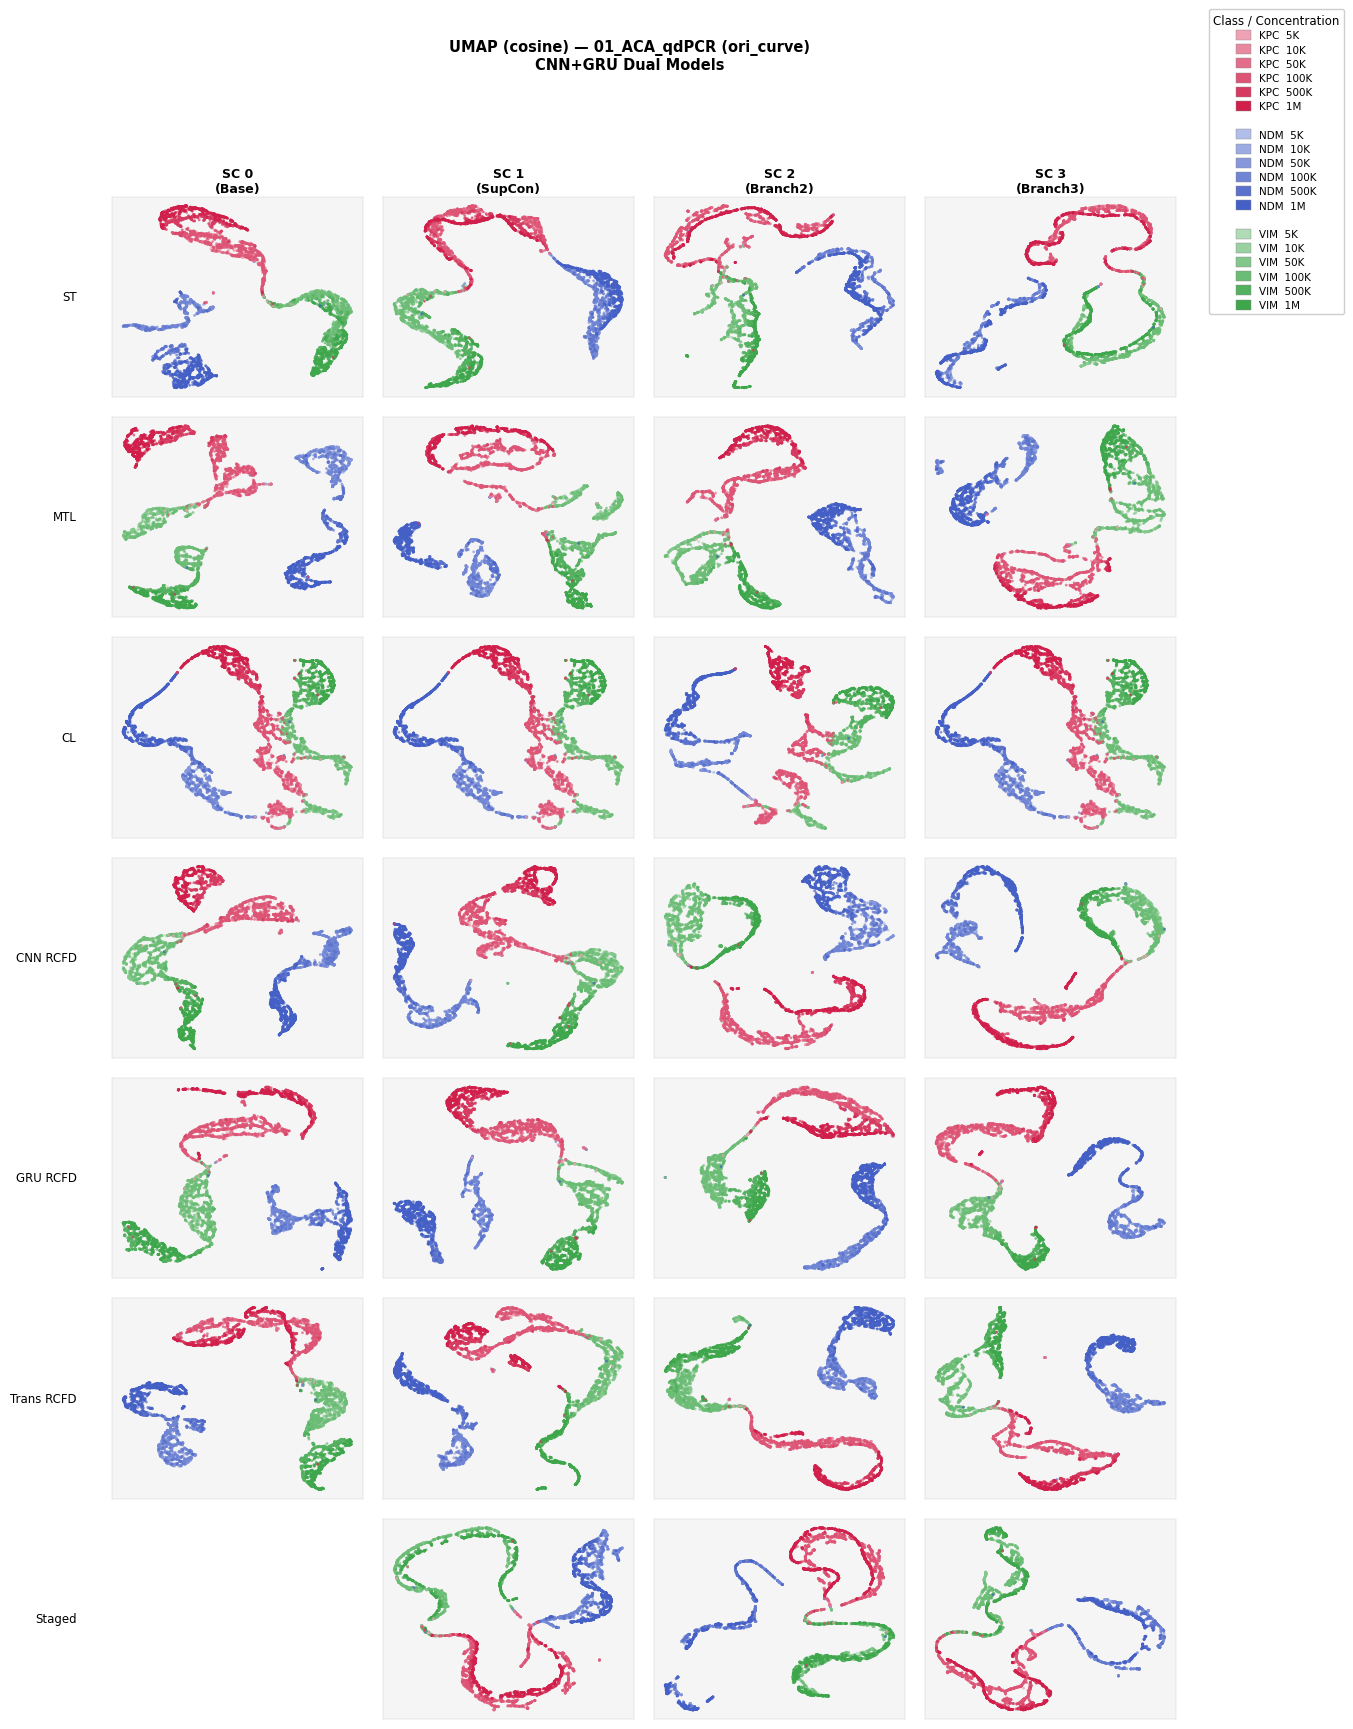


==================================================02_AMCA_qdLAMP==================================================
  Saved: umap_gru_02_AMCA_qdLAMP_ori_curve.png


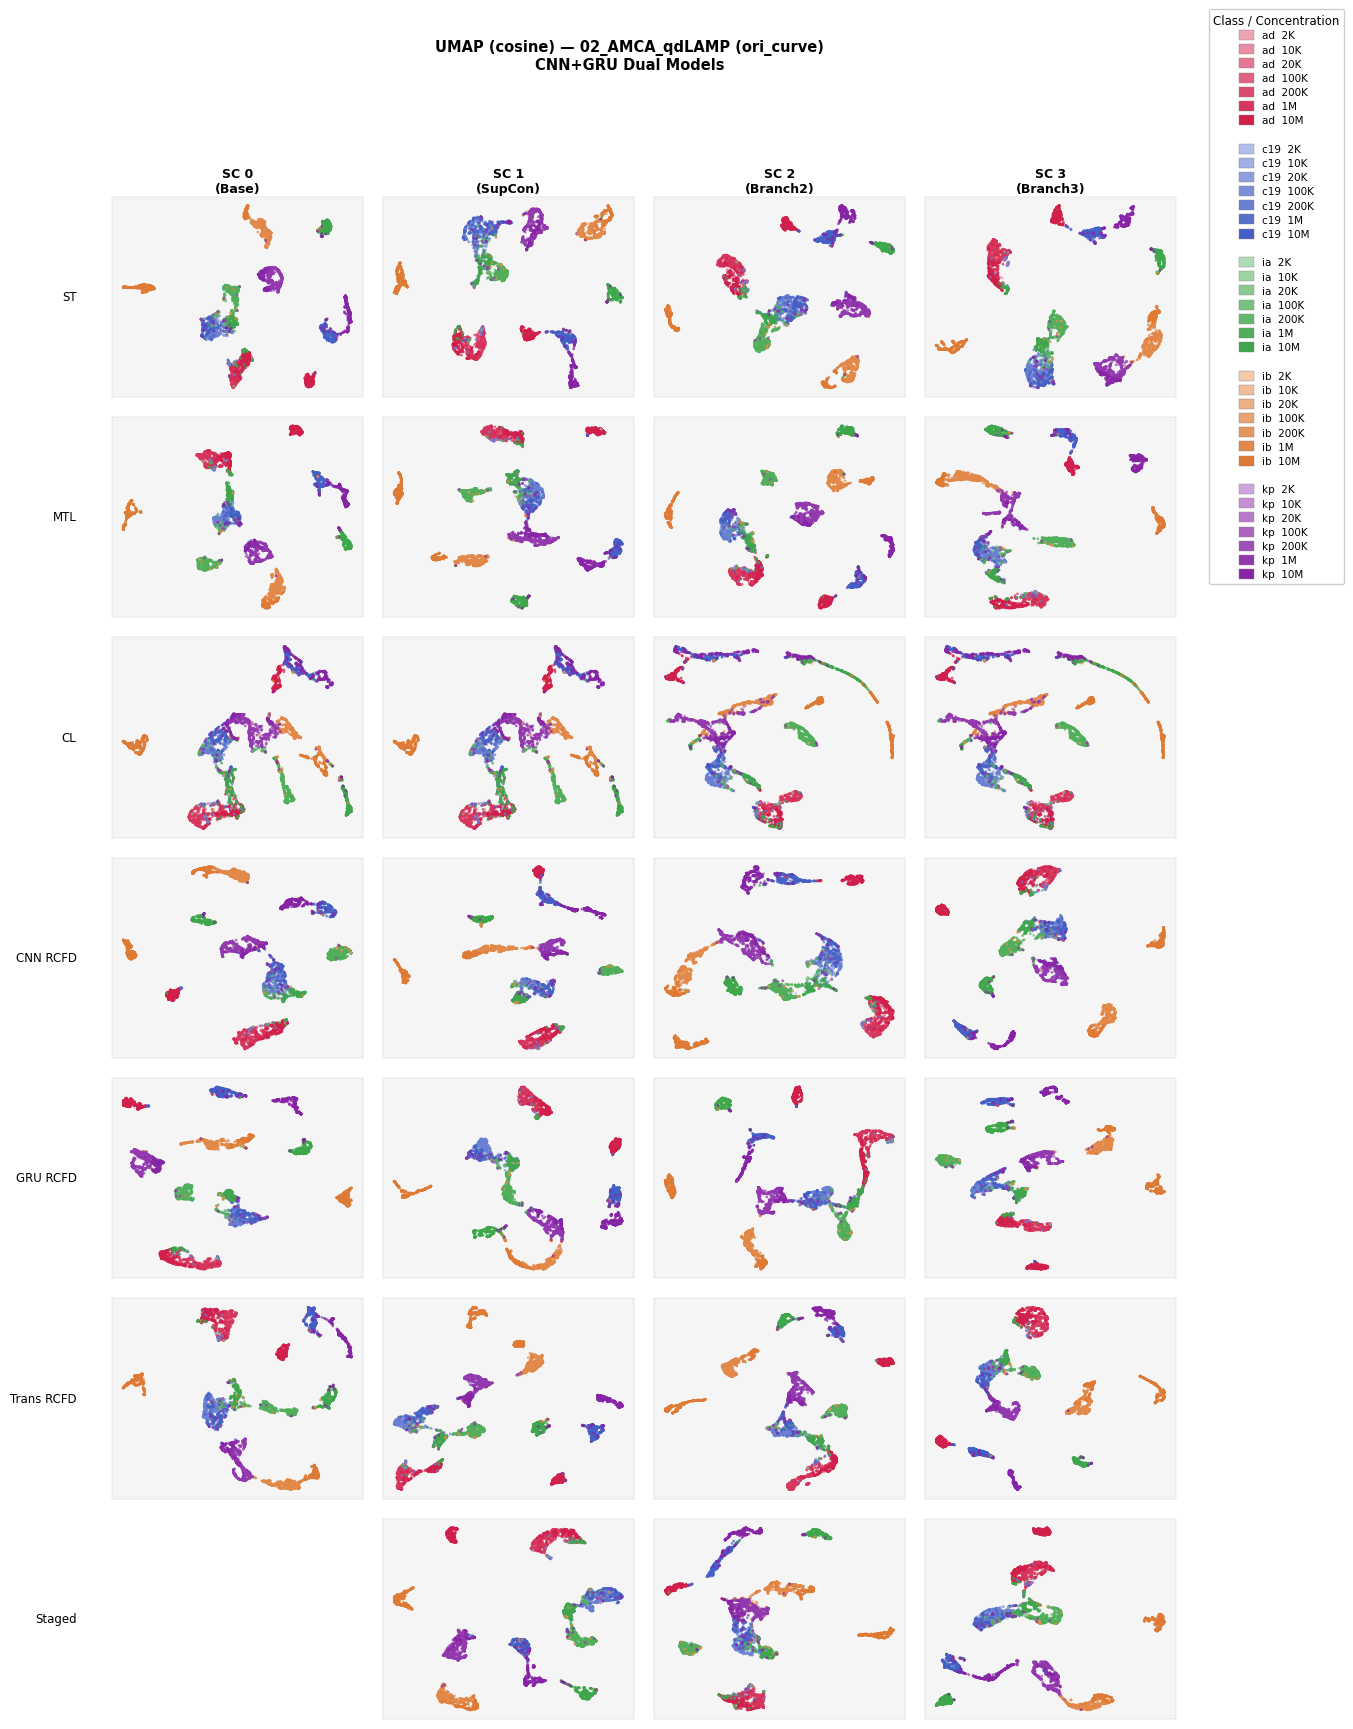


==================================================03_AMCA_qdPCR==================================================
  Saved: umap_gru_03_AMCA_qdPCR_ori_curve.png


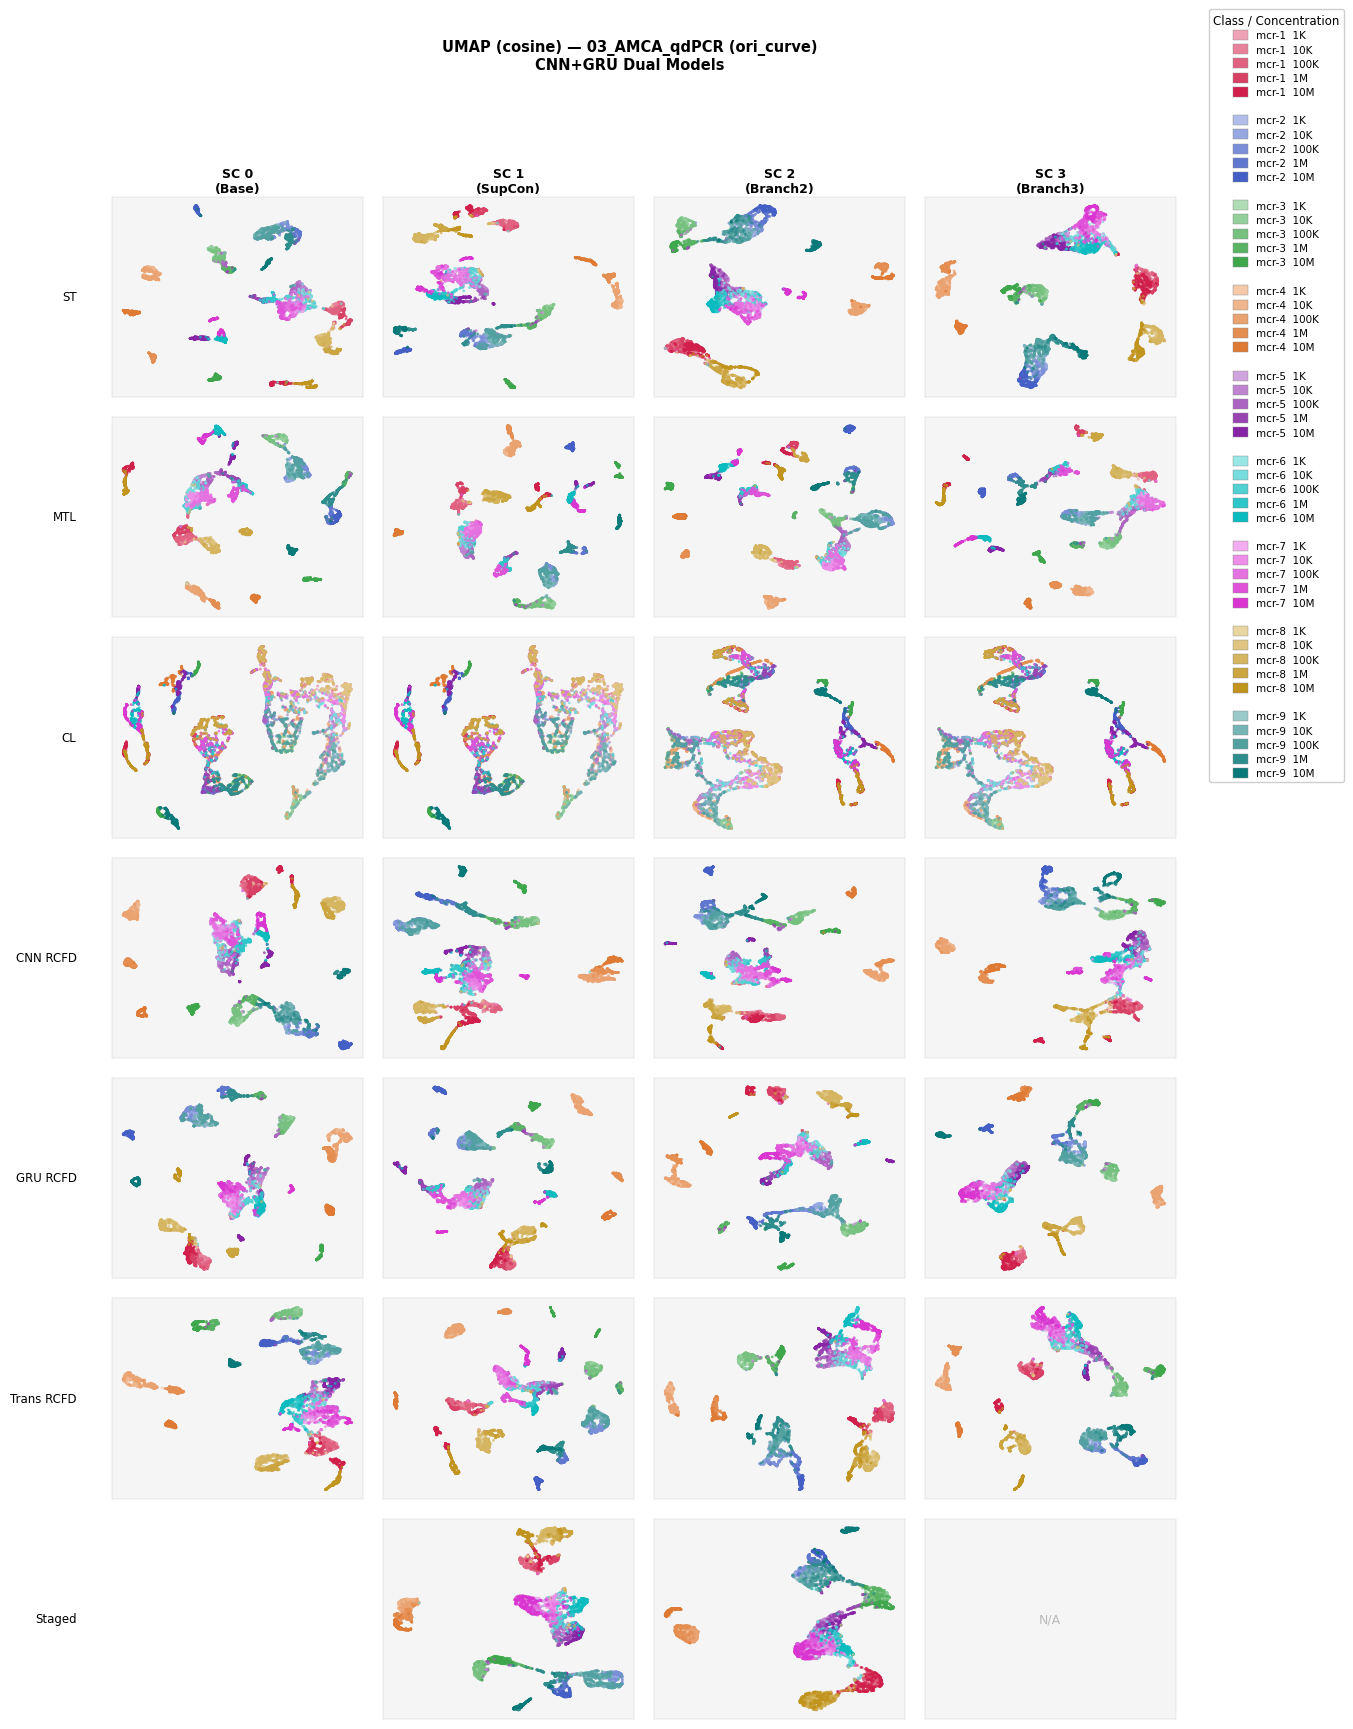


==================================================07_ACA_qdPCR_conc_filtered==================================================
  Saved: umap_gru_07_ACA_qdPCR_conc_filtered_ori_curve.png


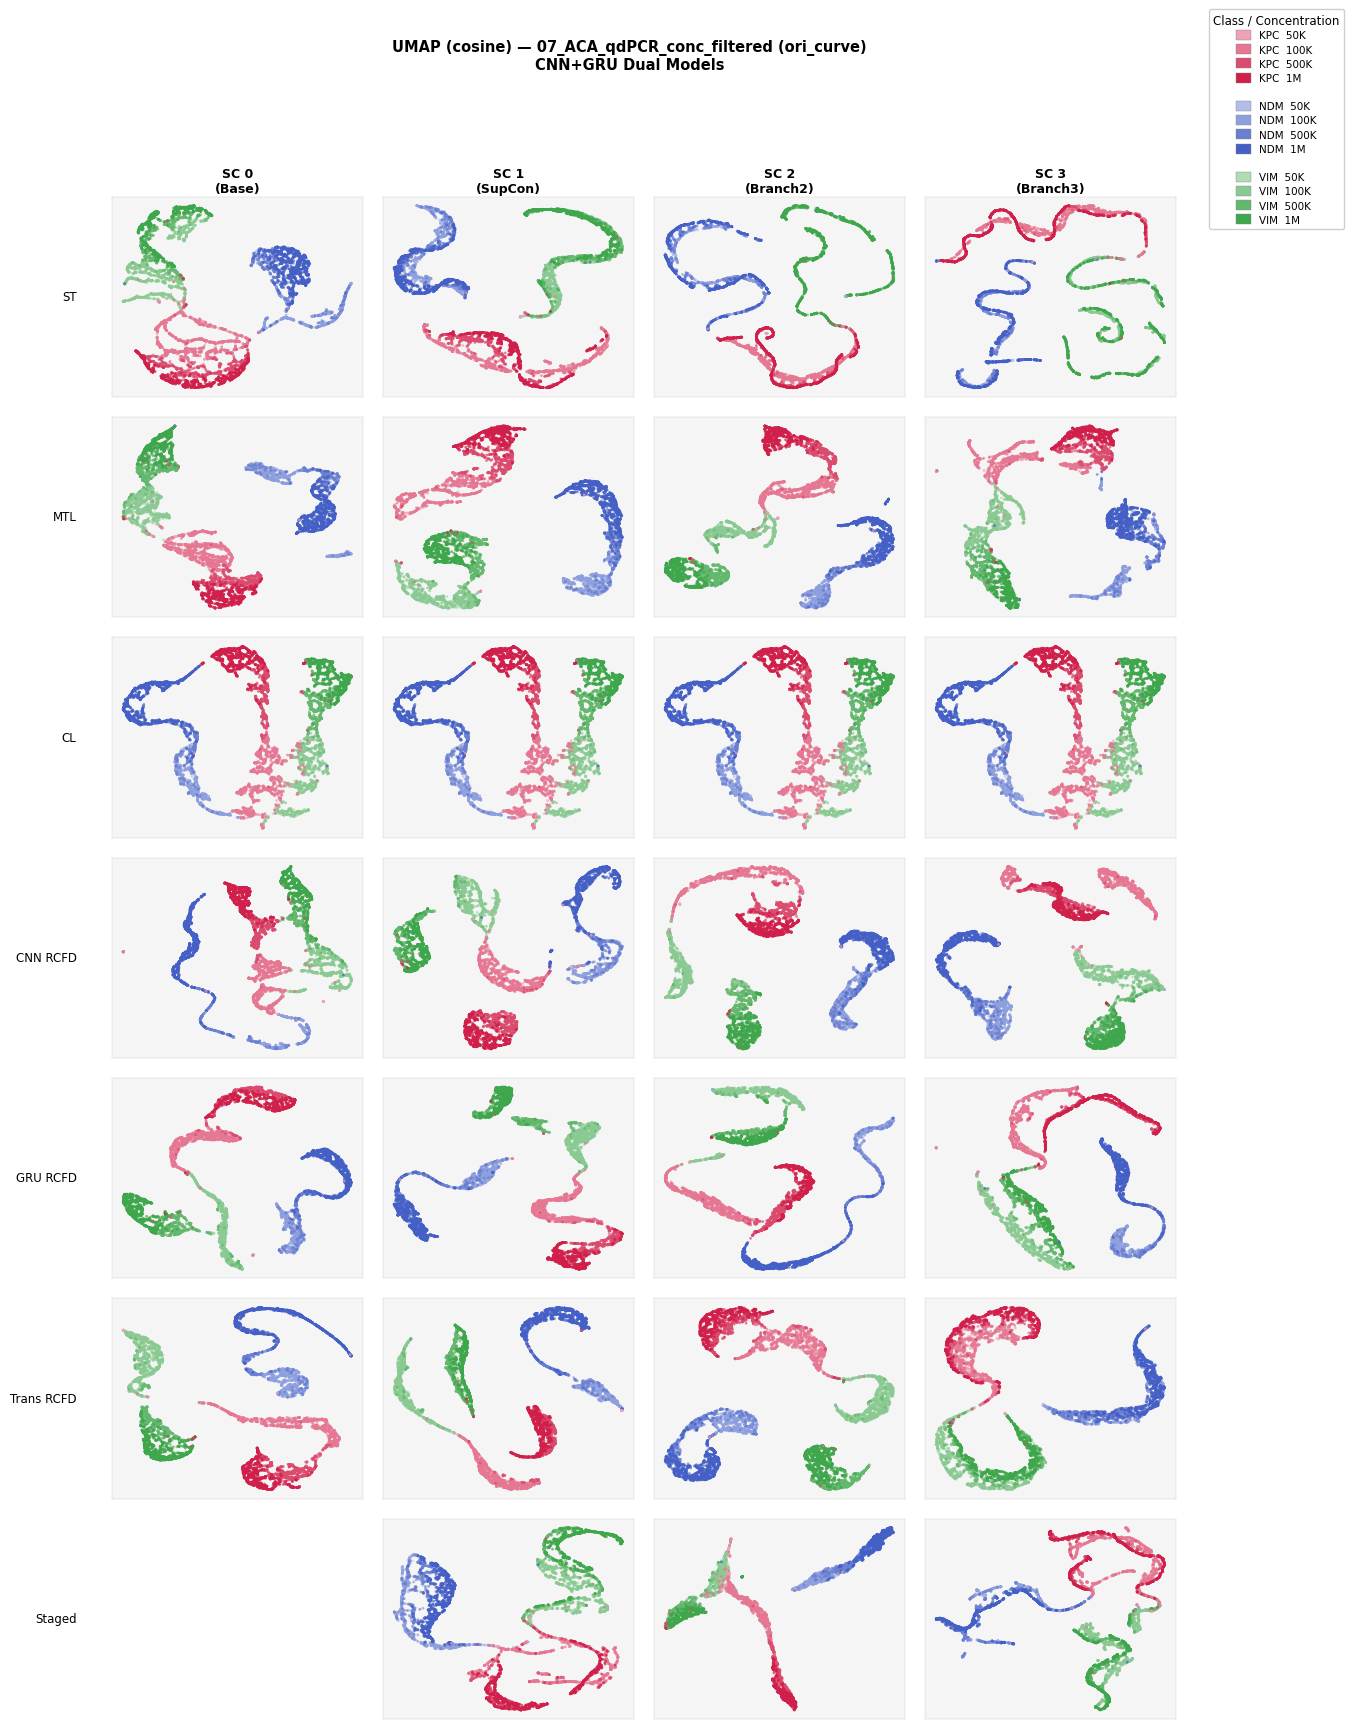


==================================================08_AMCA_qdPCR_conc_filtered==================================================
  Saved: umap_gru_08_AMCA_qdPCR_conc_filtered_ori_curve.png


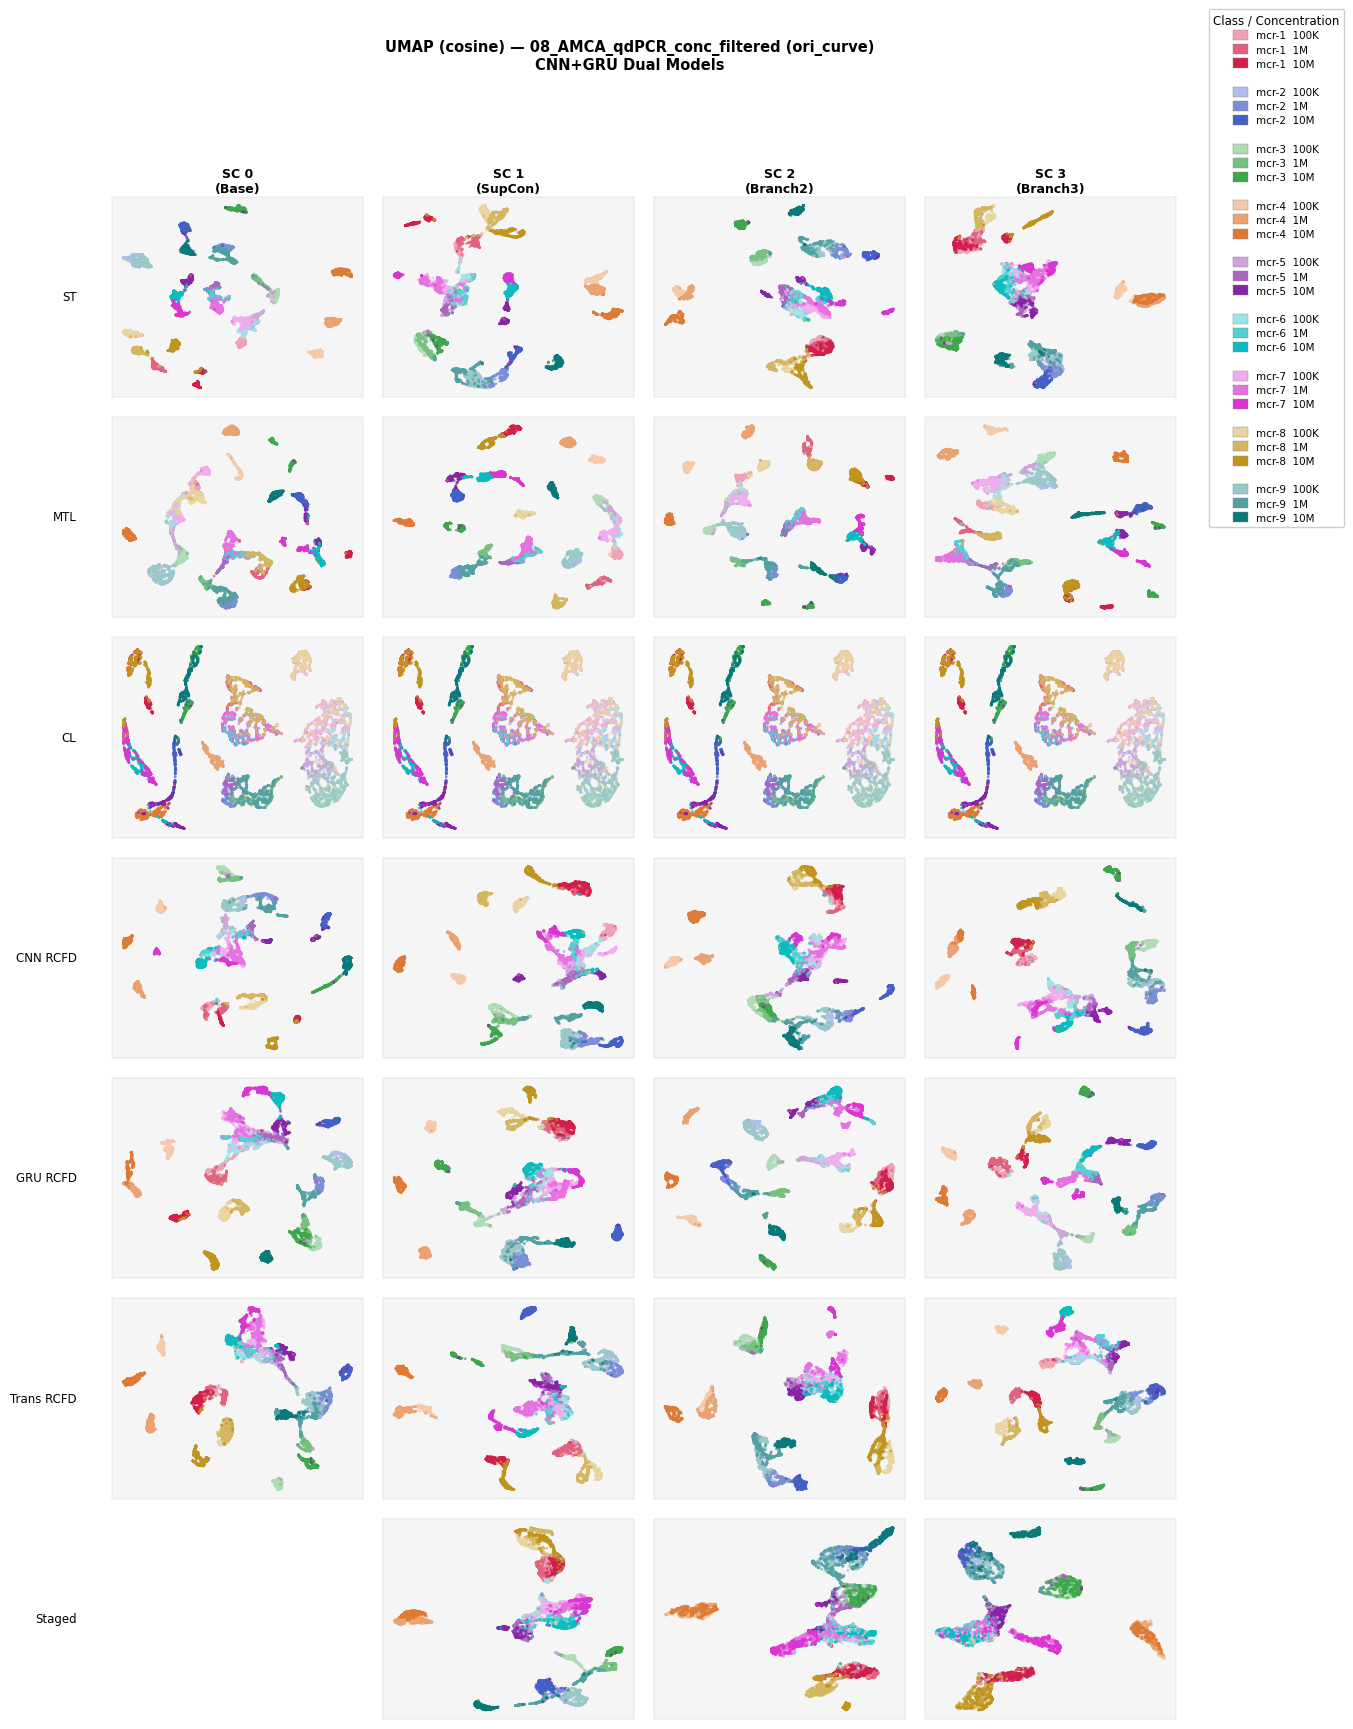


==================================================09_Area_Conc==================================================
  Saved: umap_gru_09_Area_Conc_ori_curve.png


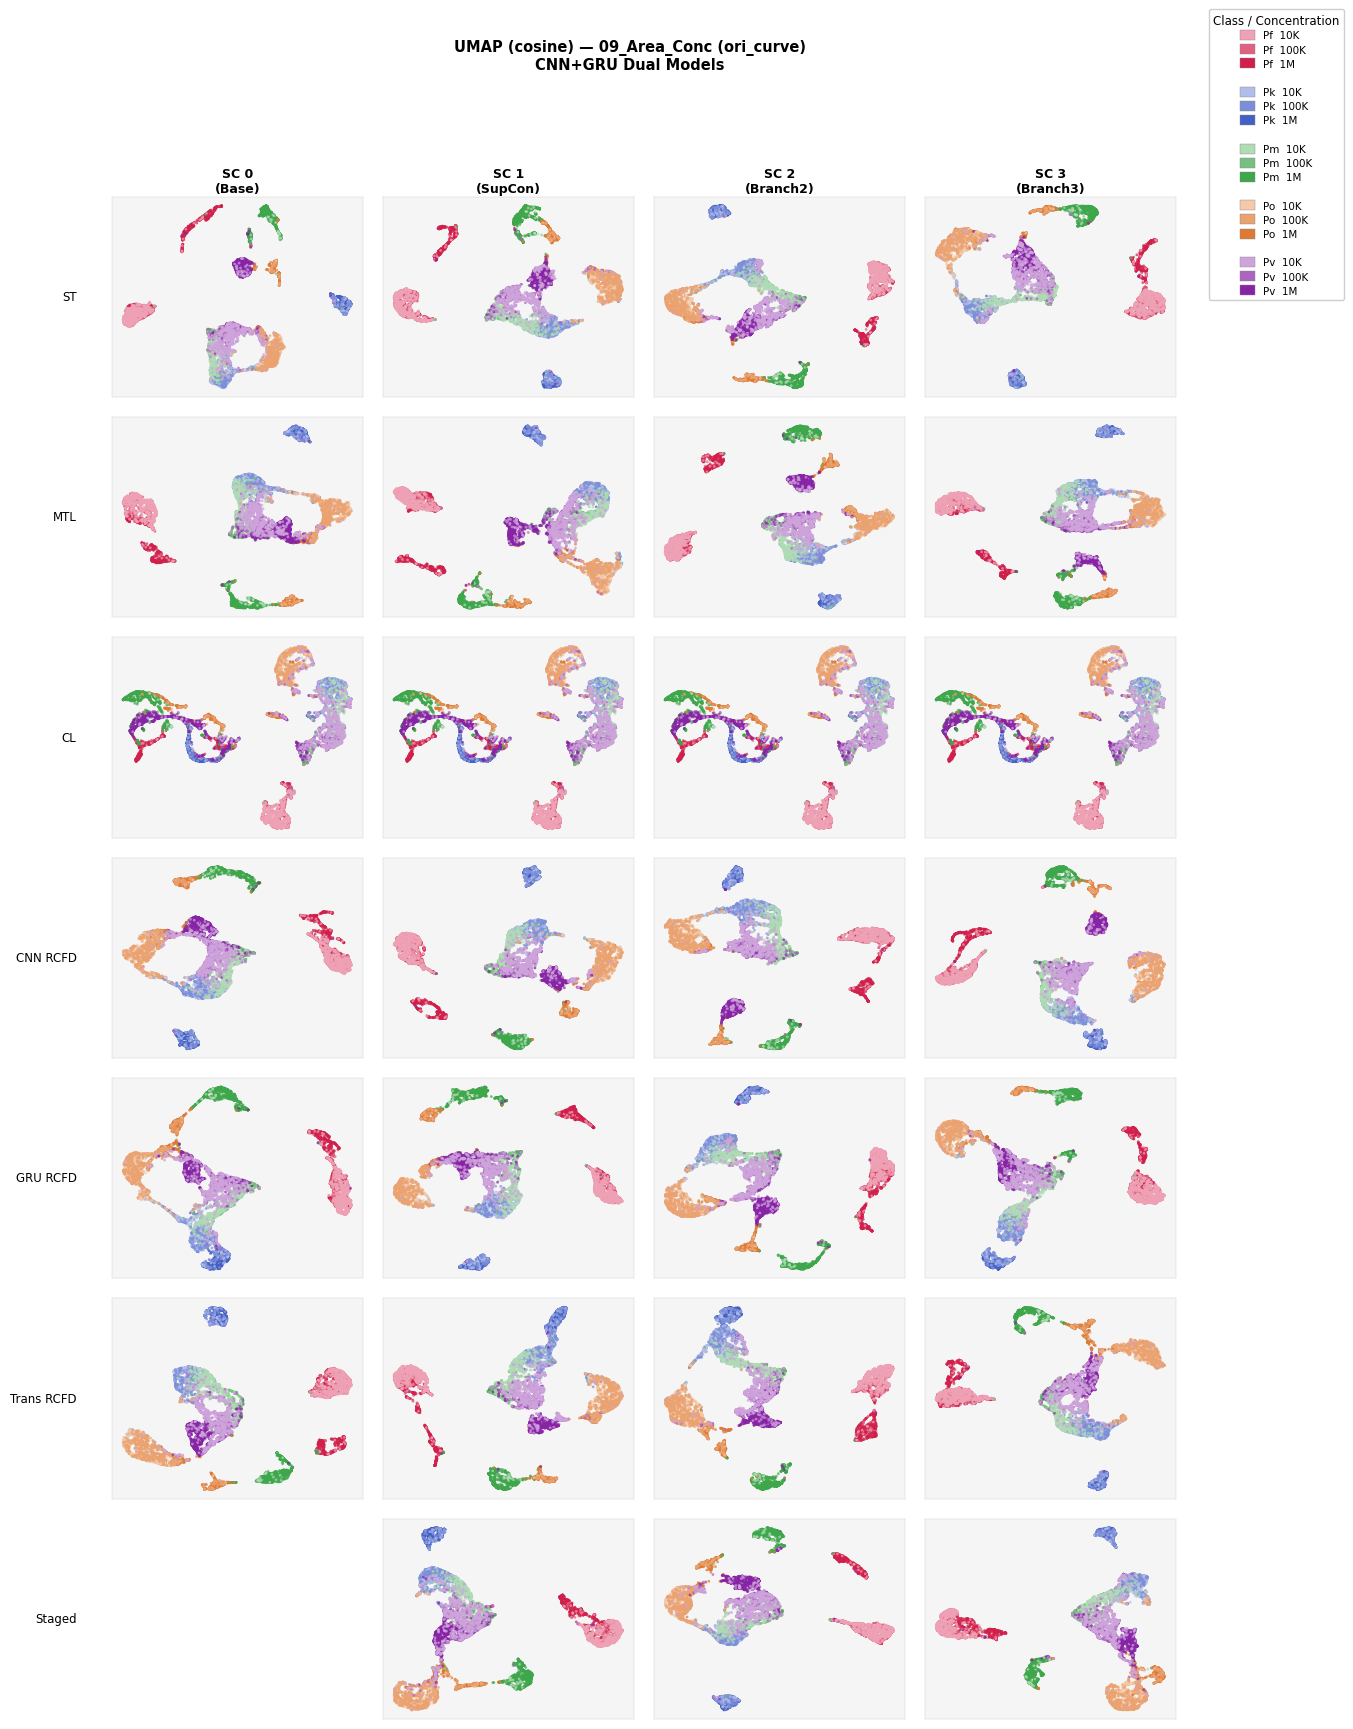


==================================================10_Range_Conc==================================================
  Saved: umap_gru_10_Range_Conc_ori_curve.png


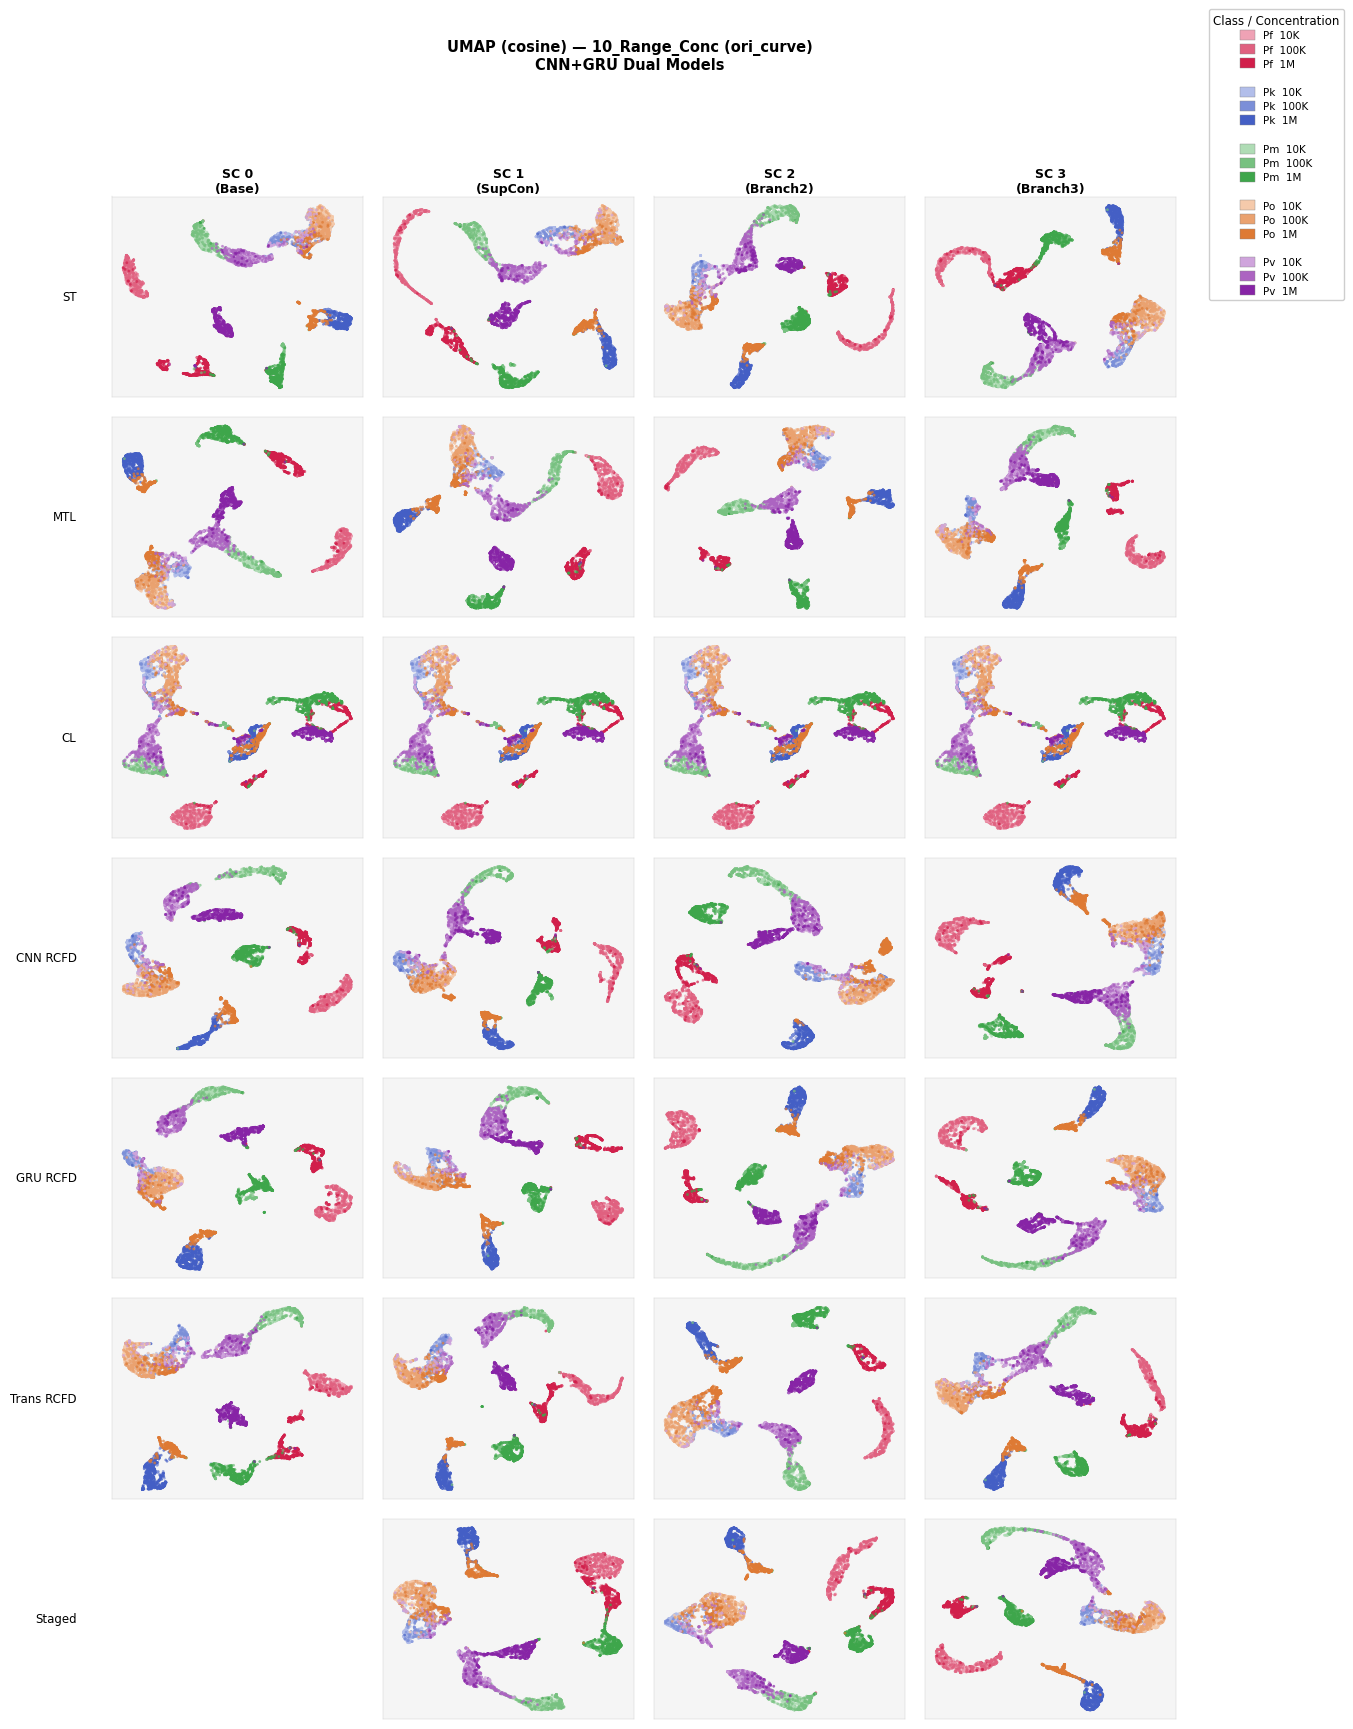

In [8]:
# ── Plot all cached UMAP results ──────────────────────────────────────────────
for _folder, _r in _umap_results.items():
    print(f'\n{"="*50}{_folder}{"="*50}')
    # plot_umap_grid(_r['umap'], _r['y'], _r['c'], _r['cs'], folder=_folder, save_dir=_r['save_dir'])
    plot_umap_grid_gru(_r['umap'], _r['y'], _r['c'], _r['cs'], folder=_folder, save_dir=_r['save_dir'])


==================================================01_ACA_qdPCR==================================================
  Saved: silhouette_gru_01_ACA_qdPCR_ori_curve.png


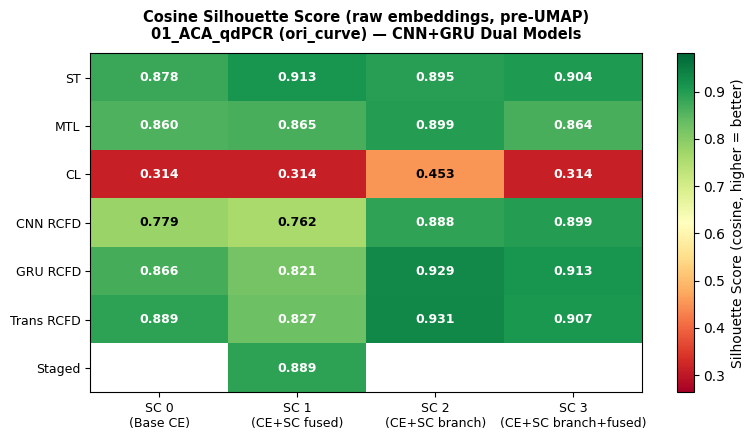


==================================================02_AMCA_qdLAMP==================================================
  Saved: silhouette_gru_02_AMCA_qdLAMP_ori_curve.png


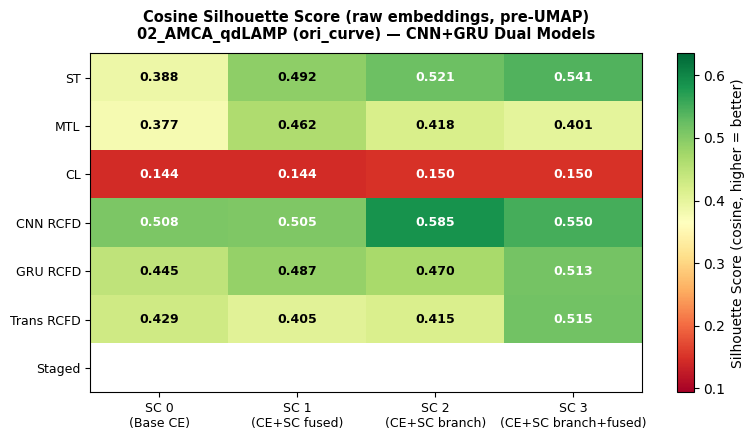


==================================================03_AMCA_qdPCR==================================================
  Saved: silhouette_gru_03_AMCA_qdPCR_ori_curve.png


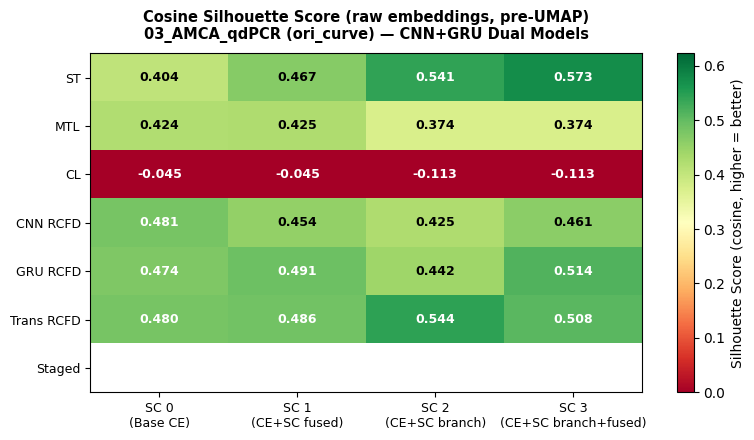


==================================================07_ACA_qdPCR_conc_filtered==================================================
  Saved: silhouette_gru_07_ACA_qdPCR_conc_filtered_ori_curve.png


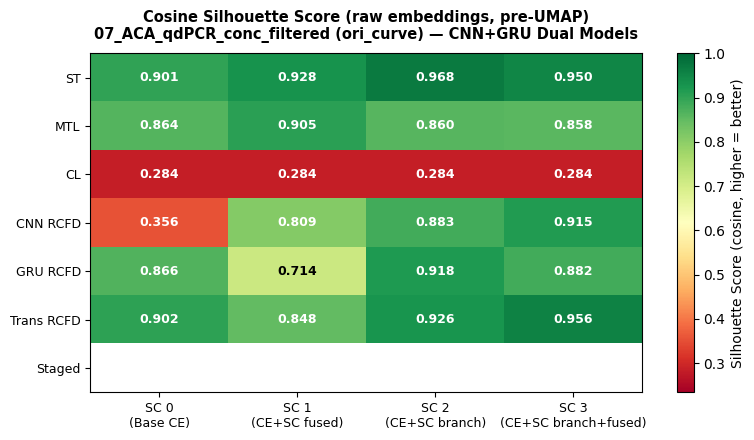


==================================================08_AMCA_qdPCR_conc_filtered==================================================
  Saved: silhouette_gru_08_AMCA_qdPCR_conc_filtered_ori_curve.png


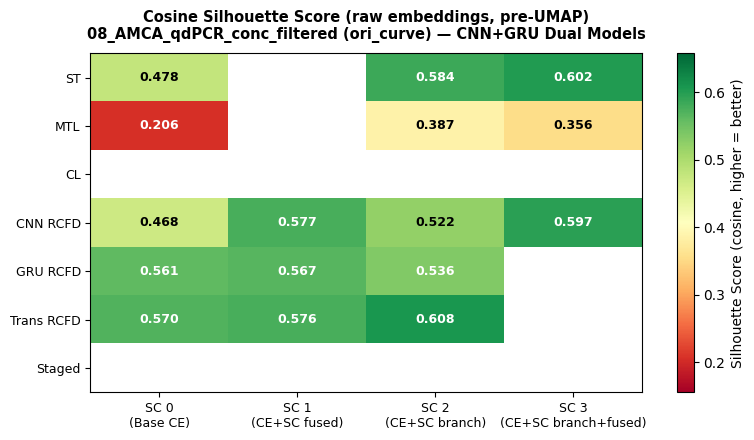


==================================================09_Area_Conc==================================================
  Saved: silhouette_gru_09_Area_Conc_ori_curve.png


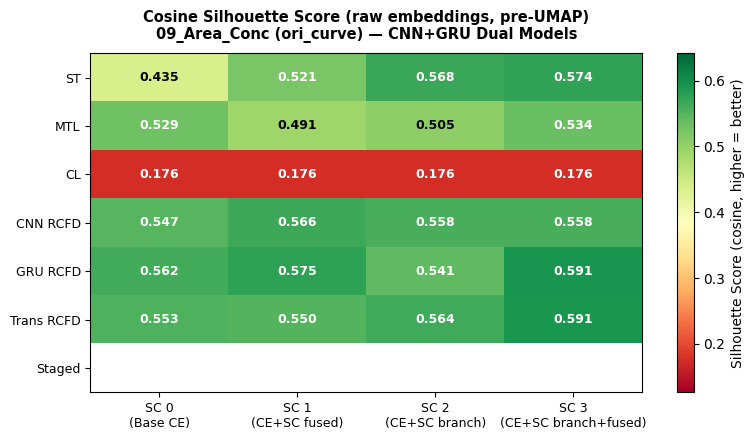


==================================================10_Range_Conc==================================================
  Saved: silhouette_gru_10_Range_Conc_ori_curve.png


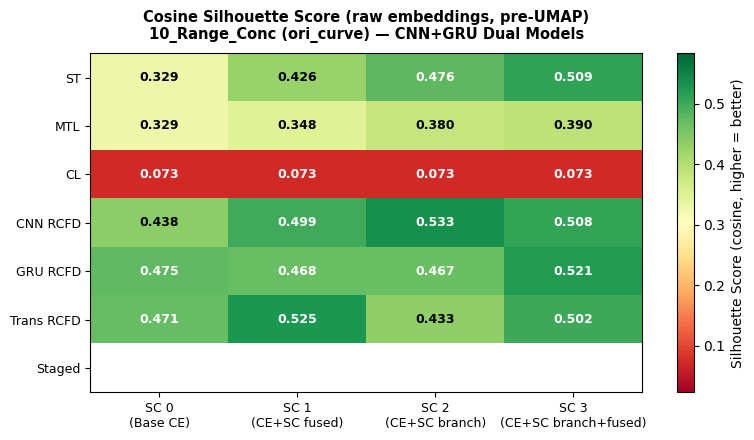

In [9]:
# ── Silhouette score heatmaps (quantitative proof, seed-independent) ──────────
for _folder, _r in _umap_results.items():
    print(f'\n{"="*50}{_folder}{"="*50}')
    plot_silhouette_grid_gru(_r['sil'], folder=_folder, save_dir=_r['save_dir'])